In [1]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
flanks = [0, 500, 1000, 2000]

In [3]:
base_results_path = '../../../results/PlantCAD2_tasks/maize_cell_type_accessible_c600/'

In [4]:
all_results = []

print("\nStarting PRAUC calculation for each model...")
for flank in flanks:
    print(f"  - Processing flank: {flank}")
    if flank == 0:
        preds_file = os.path.join(base_results_path, '2nd_pcv2-l24-d0768-checkpoints-lr-1e-4', 'test_predictions.tsv')
        labels_file = os.path.join(base_results_path, 'test.tsv')
    else:
        preds_file = os.path.join(base_results_path, f'pcv2-l24-d0768-flank-{flank}-checkpoints-lr-1e-4', f'test_flank_{flank}_predictions.tsv')
        labels_file = os.path.join(base_results_path, f'test_flank_{flank}.tsv')
    
    labels = pd.read_csv(labels_file, sep='\t')
    y_true = np.array([list(map(int, s)) for s in labels['Label']])
    preds = pd.read_csv(preds_file)
    y_scores = preds.values


    preds = pd.read_csv(preds_file)
    y_scores = preds.values


    # Calculate PRAUC for each label (i.e., each column)
    num_labels = y_true.shape[1]
    for i in range(num_labels):
        # The metric is only defined for classes with at least one positive sample
        if np.sum(y_true[:, i]) > 0:
            prauc = average_precision_score(y_true[:, i], y_scores[:, i])
            all_results.append({'flank': flank, 'PRAUC': prauc})


Starting PRAUC calculation for each model...
  - Processing flank: 0
  - Processing flank: 500
  - Processing flank: 1000
  - Processing flank: 2000


In [5]:
results_df = pd.DataFrame(all_results)

In [6]:
results_df.groupby('flank')['PRAUC'].median()

flank
0       0.664978
500     0.684753
1000    0.701115
2000    0.707127
Name: PRAUC, dtype: float64

/tmp/ipykernel_3686400/1775531596.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


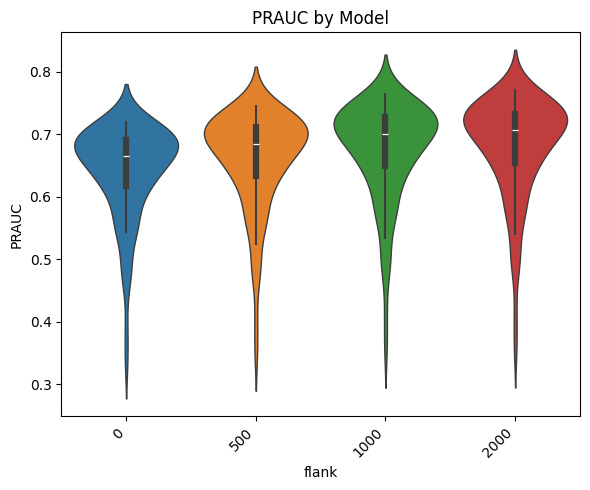

In [7]:
plt.figure(figsize=(6, 5))

custom_palette = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
sns.violinplot(
    x='flank',
    y='PRAUC',
    data=results_df,
    inner='box',
    linewidth=1,
    palette=custom_palette
)

plt.xticks(rotation=45, ha='right')
plt.title('PRAUC by Model')
plt.tight_layout()
plt.savefig(f'test_long_context_PRAUC.pdf', format='pdf', bbox_inches='tight')
plt.show()

## For validation

In [8]:
all_results = []

print("\nStarting PRAUC calculation for each model...")
for flank in flanks:
    print(f"  - Processing flank: {flank}")
    if flank == 0:
        preds_file = os.path.join(base_results_path, '2nd_pcv2-l24-d0768-checkpoints-lr-1e-4', 'valid_predictions.tsv')
        labels_file = os.path.join(base_results_path, 'valid.tsv')
    else:
        preds_file = os.path.join(base_results_path, f'pcv2-l24-d0768-flank-{flank}-checkpoints-lr-1e-4', f'valid_flank_{flank}_predictions.tsv')
        labels_file = os.path.join(base_results_path, f'valid_flank_{flank}.tsv')
    
    labels = pd.read_csv(labels_file, sep='\t')
    y_true = np.array([list(map(int, s)) for s in labels['Label']])
    preds = pd.read_csv(preds_file)
    y_scores = preds.values


    preds = pd.read_csv(preds_file)
    y_scores = preds.values


    # Calculate PRAUC for each label (i.e., each column)
    num_labels = y_true.shape[1]
    for i in range(num_labels):
        # The metric is only defined for classes with at least one positive sample
        if np.sum(y_true[:, i]) > 0:
            prauc = average_precision_score(y_true[:, i], y_scores[:, i])
            all_results.append({'flank': flank, 'PRAUC': prauc})


Starting PRAUC calculation for each model...
  - Processing flank: 0
  - Processing flank: 500
  - Processing flank: 1000
  - Processing flank: 2000


In [9]:
results_df = pd.DataFrame(all_results)

In [10]:
results_df.groupby('flank')['PRAUC'].median()

flank
0       0.690094
500     0.711126
1000    0.728479
2000    0.734293
Name: PRAUC, dtype: float64

/tmp/ipykernel_3686400/2781628485.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


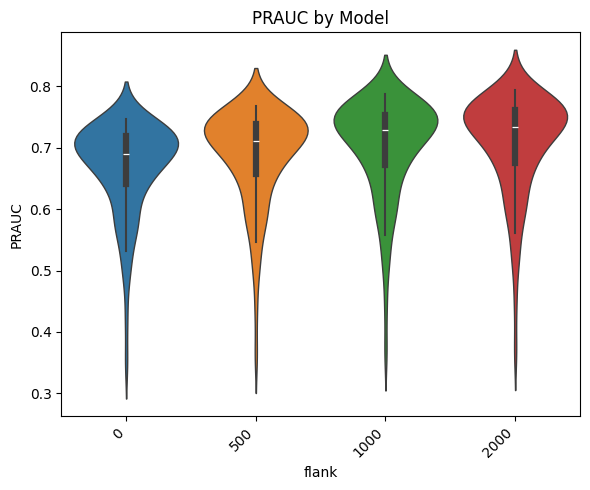

In [11]:
plt.figure(figsize=(6, 5))

custom_palette = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
sns.violinplot(
    x='flank',
    y='PRAUC',
    data=results_df,
    inner='box',
    linewidth=1,
    palette=custom_palette
)

plt.xticks(rotation=45, ha='right')
plt.title('PRAUC by Model')
plt.tight_layout()
plt.savefig(f'valid_long_context_PRAUC.pdf', format='pdf', bbox_inches='tight')
plt.show()